# Formula sub-classification demo

> This notebook loads `Bbox - DocLayoutYOLOv4.csv`,
filters formula regions, classifies them into
`chemistry` / `structured` / `inline`,
and (if `structured`) into `truth_table` / `matrix` / `vertical_arithmetic`.
Then it draws the detailed labels back onto the image.


In [6]:
from dataclasses import dataclass
from pathlib import Path
import json
import random
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class Config:
    dataset_dir: Path = Path(r"D:\--- Study ---\Nam 2 - 2025-2026\TDTT\HANDWRITTEN\Handwritten_to_Data_Ukraine\Dataset\test")
    images_dir: Path = dataset_dir / "images"
    bbox_csv: Path = dataset_dir / "Bbox - DocLayoutYOLOv4.csv"
    sample_size: int = 10
    seed: int = 7


config = Config()


def parse_regions(value):
    if not isinstance(value, str):
        return []
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return []


def safe_crop(image, bbox):
    if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
        return None, None
    h, w = image.shape[:2]
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    x1 = max(0, min(x1, w - 1))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h - 1))
    y2 = max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None, None
    return image[y1:y2, x1:x2], (x1, y1, x2, y2)


def classify_formula_branch(crop_img, ocr_text=None):
    """
    crop_img: numpy array (H, W, 3)
    ocr_text: string if available, otherwise None
    Returns: 'chemistry' | 'structured' | 'inline'
    """
    # Layer 0: use OCR text if available
    if ocr_text is not None and ocr_text.strip():
        chem_pattern = (
            r"\b(CH|CO2?|OH|H2O|NaCl|KOH|HCl|H2SO4|"
            r"Cl|Br|Al|Na|Ca|Fe|Cu|Zn|Mg|NO3|SO4)\b"
        )
        if re.search(chem_pattern, ocr_text):
            return "chemistry"
        has_newline = "\n" in ocr_text
        has_pipe = "|" in ocr_text
        has_struct = bool(
            re.search(r"\\begin\{(array|matrix|tabular|pmatrix|bmatrix|vmatrix)", ocr_text)
        )
        if has_newline or has_pipe or has_struct:
            return "structured"
        return "inline"

    # Layer 1: image-only heuristic
    h, w = crop_img.shape[:2]
    if h < 10 or w < 10:
        return "inline"
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    aspect = w / max(h, 1)
    n_rows_estimated = max(1, round(h / 28))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(20, w // 4), 1))
    h_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, h_kernel)
    n_hlines = cv2.countNonZero(h_lines)
    has_hline = n_hlines > w * 0.3

    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(15, h // 3)))
    v_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, v_kernel)
    n_vlines = cv2.countNonZero(v_lines)
    has_vline = n_vlines > h * 0.25

    row_projection = np.sum(bw, axis=1)
    valleys = np.sum(row_projection < row_projection.max() * 0.1)
    multi_line = (n_rows_estimated >= 2) and (valleys > h * 0.3)

    if has_hline or has_vline or multi_line or aspect > 3.0:
        return "structured"
    return "inline"


def classify_structured_subtype(crop_img, ocr_text=None):
    """
    Returns: 'truth_table' | 'matrix' | 'vertical_arithmetic'
    """
    h, w = crop_img.shape[:2]
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    if ocr_text is not None and ocr_text.strip():
        truth_tokens = r"\b[TF01]\b|→|↔|∧|∨|¬"
        matrix_tokens = r"\\begin\{[pPbBvV]?matrix\}|\[|\(.*\d.*\)"
        if re.search(truth_tokens, ocr_text) and "|" in ocr_text:
            return "truth_table"
        if re.search(matrix_tokens, ocr_text):
            return "matrix"
        if re.search(r"\\hline|__+", ocr_text) and w < h * 2:
            return "vertical_arithmetic"

    aspect = w / max(h, 1)
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(15, w // 3), 1))
    h_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, h_kernel)
    n_hlines, _, _, _ = cv2.connectedComponentsWithStats(h_lines)
    n_hlines = max(0, n_hlines - 1)
    if aspect < 1.5 and n_hlines >= 2:
        return "vertical_arithmetic"

    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(10, h // 3)))
    v_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, v_kernel)
    left_col = np.sum(v_lines[:, : w // 6])
    right_col = np.sum(v_lines[:, 5 * w // 6 :])
    mid_col = np.sum(v_lines[:, w // 3 : 2 * w // 3])
    if left_col > 0 and right_col > 0 and mid_col < left_col * 0.3:
        return "matrix"

    return "truth_table"


def pick_color(branch, subtype=None):
    if branch == "chemistry":
        return (0, 200, 0)
    if branch == "structured":
        return (255, 0, 0)
    return (0, 165, 255)


def draw_boxes(image, boxes):
    font_scale = 0.9
    thickness = 2
    for (x1, y1, x2, y2), label, color in boxes:
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        (text_w, text_h), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
        )
        if y1 - 8 > text_h + baseline:
            text_y = y1 - 8
        else:
            text_y = y1 + text_h + 8
        cv2.putText(
            image,
            label,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            color,
            thickness,
            cv2.LINE_AA,
        )
    return image

Sampling 10 images with formula boxes...


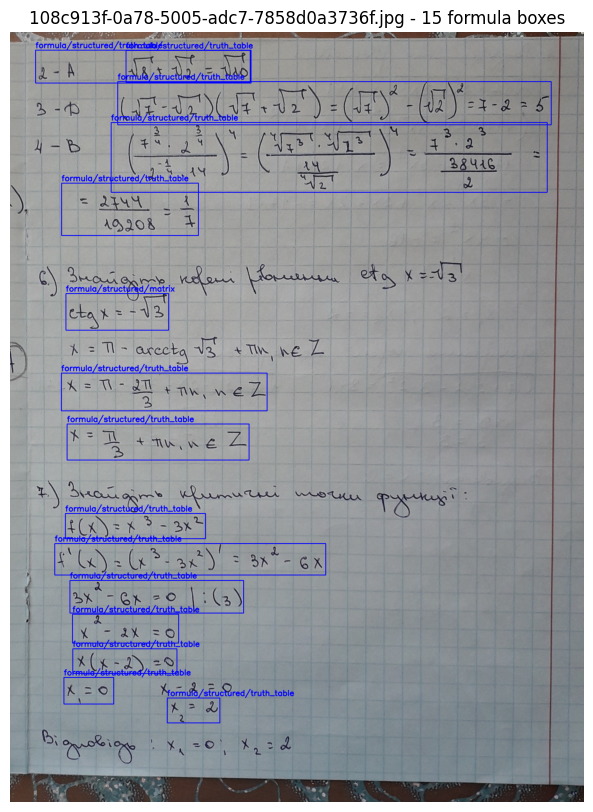

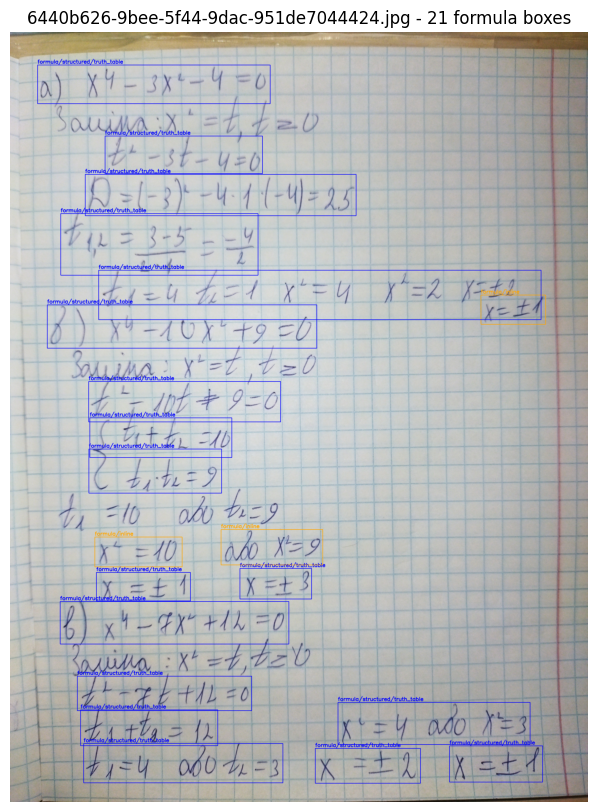

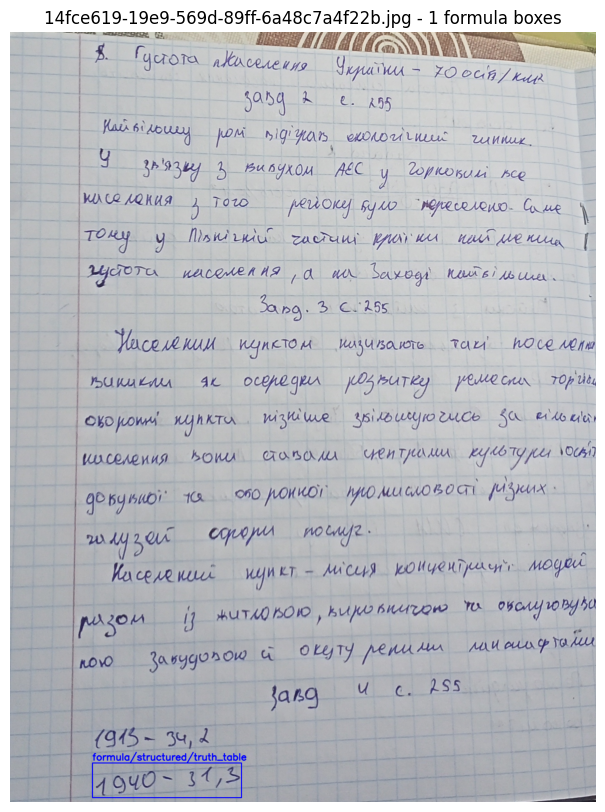

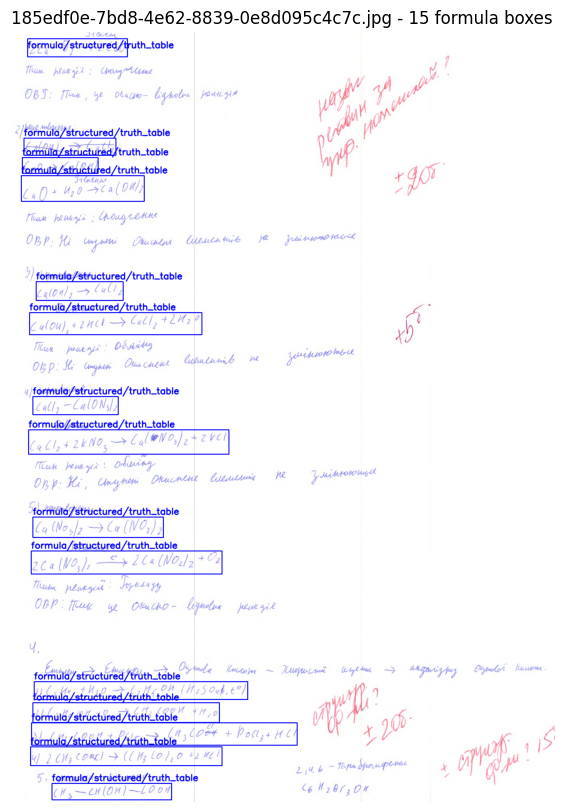

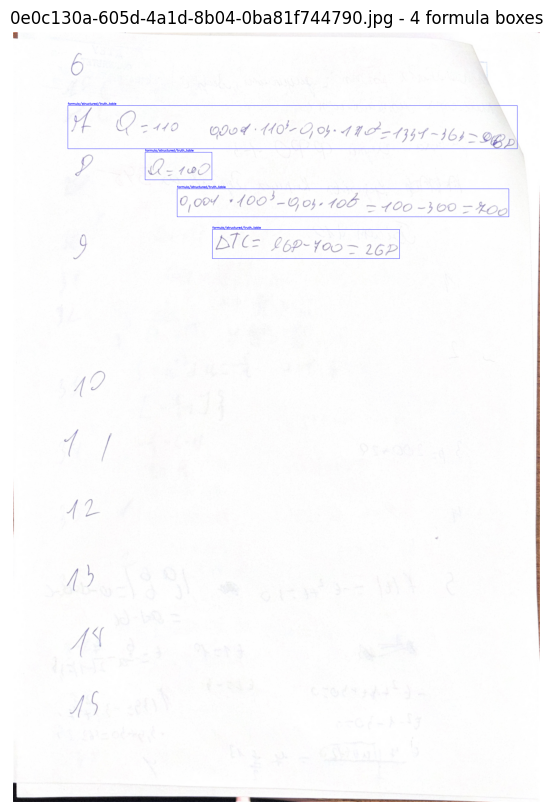

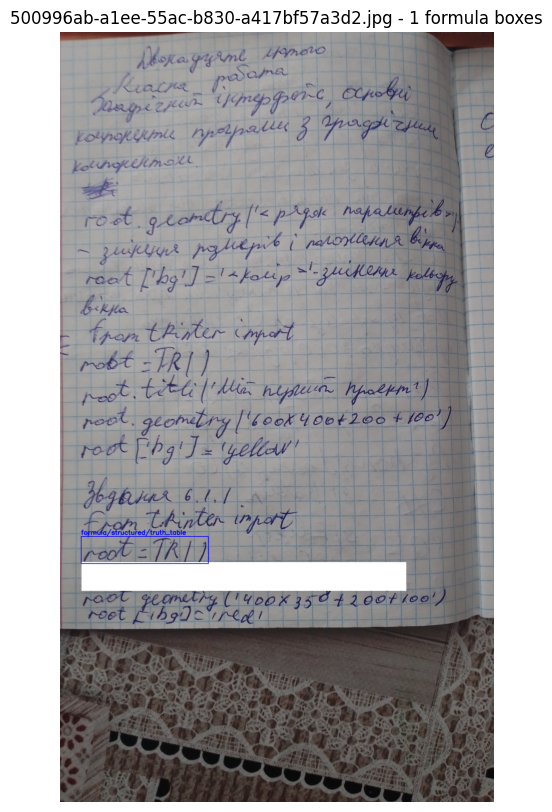

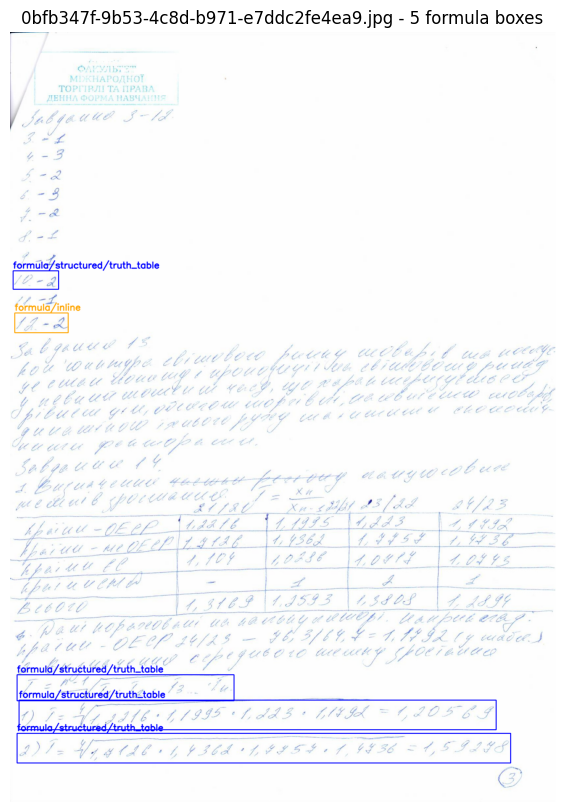

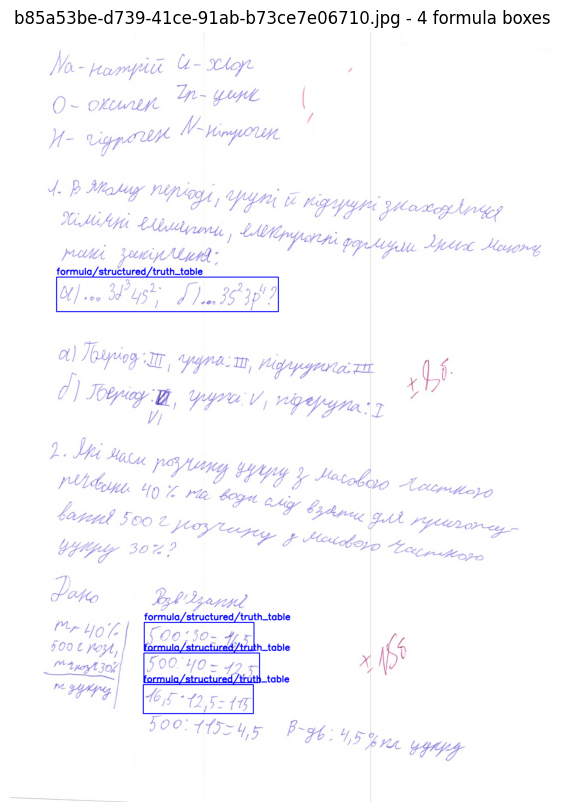

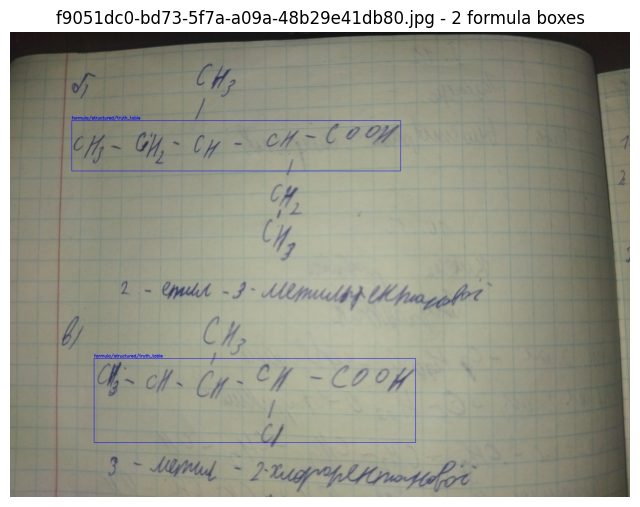

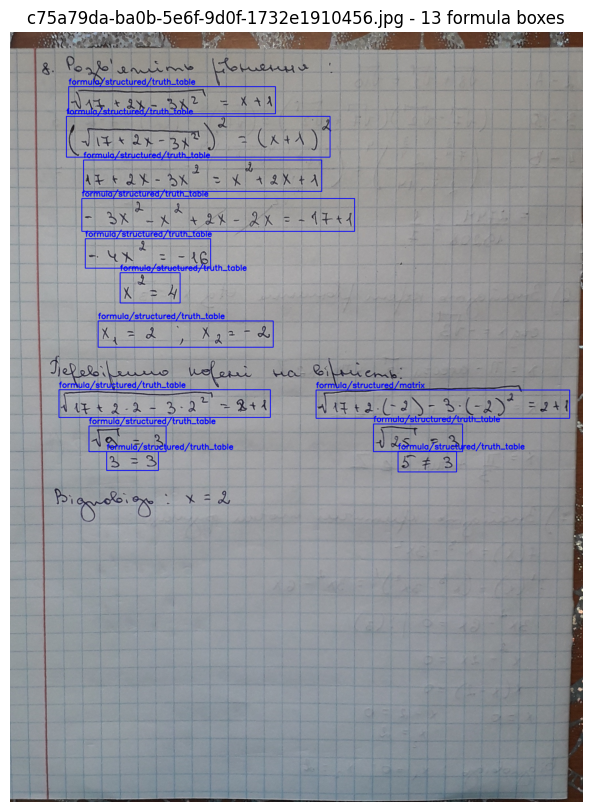

In [7]:
df = pd.read_csv(str(config.bbox_csv))
df["regions"] = df["regions"].apply(parse_regions)
df["has_formula"] = df["regions"].apply(
    lambda regions: any(r.get("type") == "formula" for r in regions)
    if isinstance(regions, list)
    else False
    )

formula_df = df[df["has_formula"]].reset_index(drop=True)
if formula_df.empty:
    print("No formula boxes found in CSV.")
else:
    sample_n = min(config.sample_size, len(formula_df))
    sample_df = formula_df.sample(n=sample_n, random_state=config.seed)
    print(f"Sampling {sample_n} images with formula boxes...")

    for _, row in sample_df.iterrows():
        img_path = config.images_dir / row["image"]
        image = cv2.imread(str(img_path))
        if image is None:
            print(f"Skip missing image: {img_path}")
            continue

        boxes = []
        for region in row["regions"]:
            if region.get("type") != "formula":
                continue
            crop, clipped_bbox = safe_crop(image, region.get("bbox", []))
            if crop is None:
                continue
            ocr_text = region.get("text")
            if not isinstance(ocr_text, str) or not ocr_text.strip():
                ocr_text = None

            branch = classify_formula_branch(crop, ocr_text)
            if branch == "structured":
                subtype = classify_structured_subtype(crop, ocr_text)
                label = f"formula/structured/{subtype}"
            else:
                subtype = None
                label = f"formula/{branch}"
            color = pick_color(branch, subtype)
            boxes.append((clipped_bbox, label, color))

        if not boxes:
            continue
        drawn = draw_boxes(image.copy(), boxes)
        rgb = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 10))
        plt.imshow(rgb)
        plt.title(f"{row['image']} - {len(boxes)} formula boxes")
        plt.axis("off")
        plt.show()